In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)


from IPython.display import display, Math

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


### Procedure

1. Find peaks of $\Delta I$ at $t_0$
2. Extract $c(t0+\Delta t)$ 
3. Use $I,t$ as inputs and compare to $c$


In [3]:
dI = np.load('data_c_dot1.npz')['I_dot']
dc = np.load('data_c_dot1.npz')['cn_dot']

In [4]:
dI = dI.reshape(dI.shape[0],dI.shape[1])
dc = dc.reshape(dc.shape[0],dc.shape[1])

Text(0, 0.5, '$\\dot{I}$')

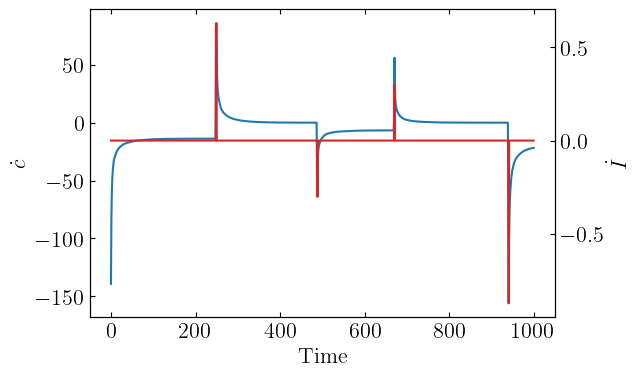

In [5]:
f, ax = plt.subplots(figsize=(6,4))
ax.plot(dc[0,:])
axt = ax.twinx()
axt.plot(dI[0,:],color = 'tab:red')
ax.set_xlabel('Time')
ax.set_ylabel(r'$\dot{c}$')
axt.set_ylabel(r'$\dot{I}$')

In [6]:
peak_idx = np.where(dI[:,:]>0.01,1,0)

lag = 15
dc_decays = []
dI_decay = []
for j,row in enumerate(peak_idx):
    short_idx = np.where(row==1)[0]
    for i in short_idx:
        if i+lag < dc.shape[1]:
            dc_decays = np.append(dc_decays,dc[j,i:i+lag].flatten())
            dI_decay = np.append(dI_decay,dI[j,i] * np.ones(lag))

decays = dc_decays.reshape(int(dc_decays.shape[0]/lag),lag)
dI_decay = dI_decay.reshape(int(dI_decay.shape[0]/lag),lag)

t_decay =np.ones_like(decays) * (np.arange(lag)+1)
print(t_decay[0,:])
inputs = dI_decay

X = np.column_stack([
    dI_decay.flatten(),
    t_decay.flatten()
])

y = decays.flatten()

print(X.shape)      # (7129*30, 2)
print(y.shape) # (7129*30,)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
(53805, 2)
(53805,)


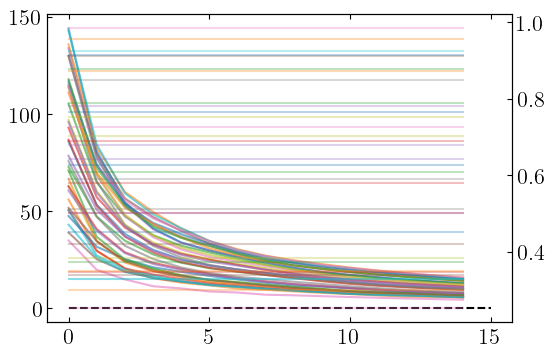

In [7]:
rand_idx = np.random.choice(decays.shape[0], size=100, replace=False)







f,ax = plt.subplots(figsize=(6,4))
axt = ax.twinx()
for i in range(int(decays.shape[0]/100)):
    ax.plot(decays[i,:], alpha = 0.6)
    axt.plot(dI_decay[i,:], alpha = 0.3)

ax.hlines(0,0,lag, color = 'k', linestyle = '--')


In [8]:
# template = TemplateExpressionSpec(
#     expressions=['f', 'g','h'],
#     variable_names=["x0", "x1"],
#     combine = 'f(x0) * exp(g(x1)) + h(x0,x1)' 
# )

In [49]:
model = PySRRegressor(
    model_selection="accuracy",
    niterations=200,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['exp','sqrt','log'],
    elementwise_loss="loss(x, y) = mean((x - y).^2)",
    populations=15,
    verbosity=1, 
    batching = True,
    batch_size = 1000,
    maxsize = 20,
)

In [50]:
model.fit(X, y)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 7.200e+03
Progress: 661 / 3000 total iterations (22.033%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.255e+02  0.000e+00  y = 26.639
3           1.934e+02  5.868e-01  y = 104.04 / x₁
5           5.593e+01  6.204e-01  y = (x₀ * 166.61) / x₁
7           2.461e+01  4.104e-01  y = x₀ * (240.91 / (x₁ + 0.64576))
8           2.416e+01  1.880e-02  y = (x₀ * 302.18) / (x₁ + sqrt(x₁))
10          2.385e+01  6.480e-03  y = (x₀ * 315.26) / ((x₁ + sqrt(x₁)) - -0.13295)
12          2.380e+01  9.474e-04  y = (x₀ * 31.939) * ((log(x₁) + 5.1938) / (x₁ + 0.11141))
14          2.380e+01  3.788e-05  y = (((log(x₁ + -0.29027) + 5.0702) * 31.537) * (x₀ / x₁))...
                                       + 0.40563
15          2.377e+01  1.098e-03  y = (x₀ * (18.998 

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'accuracy'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['exp', 'sqrt', ...]"
,expression_spec,None
,niterations,200
,populations,15
,population_size,27
,max_evals,None
,maxsize,20
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260226_162844_Sm1ryy/hall_of_fame.csv


In [52]:
model_index = None
display(Math('\\Large '+ model.latex(model_index)))

<IPython.core.display.Math object>

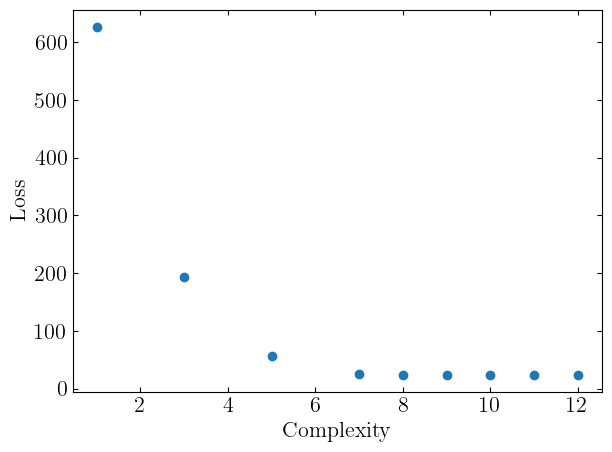

In [12]:
df = model.equations_


plt.scatter(df['complexity'], df['loss'])

plt.xlabel('Complexity')
plt.ylabel('Loss')

plt.tight_layout()

In [41]:
def f_decay(X, a,b,c,d):
    return a*X[:,0]/(X[:,1]**(d)) + c + 0.01*X[:,1]

import scipy.optimize as opt

popt, pcov = opt.curve_fit(f_decay, X, y)

print(popt)



/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_54234/1087984948.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = opt.curve_fit(f_decay, X, y)


[150.72018332   1.          -0.56600566   0.78126549]


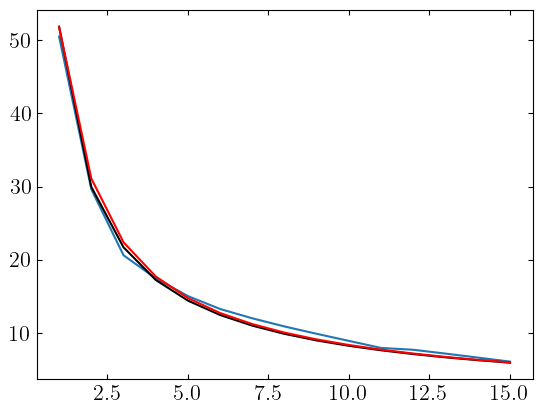

In [57]:

j = 3
X_fit = np.column_stack([
    dI_decay[j,:].flatten(),
    t_decay[j,:].flatten()
])
plt.plot(X_fit[:,1],decays[j,:])

plt.plot(X_fit[:,1], f_decay(X_fit, *popt), color = 'k', label = 'Curve fit' )

plt.plot(X_fit[:,1], model.predict(X_fit), color = 'r', label = 'Symbolic regression' )

#plt.plot(X[ind,1], f_decay(X[ind,:], *popt), color = 'k', label = 'Curve fit' )

In [58]:
y_pred = model.predict(X)
y_pred = y_pred.reshape(decays.shape[0],decays.shape[1])    

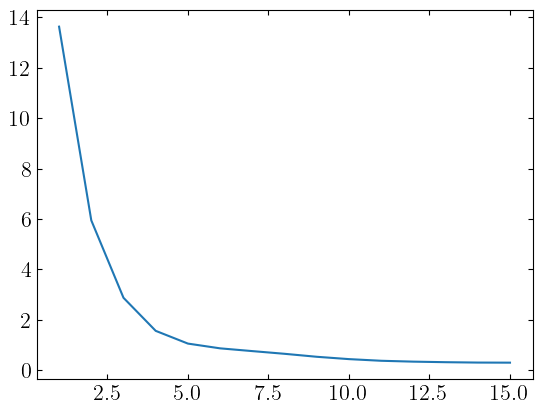

In [59]:
e_mean = np.mean(np.abs(y_pred - decays),axis = 0)
plt.plot(t_decay[0,:],e_mean)